# **랭체인 Multi-modal RAG 구현**

## **학습 목표**

- Unstructured 라이브러리를 활용한 PDF 멀티모달 파싱 이해
- CLIP 임베딩 기반 멀티모달 RAG 시스템 구현
- 이미지-텍스트 공동 검색 파이프라인 구축

## **사전 준비**

- Python 3.10 이상
- 필수 패키지: `langchain-experimental`, `langchain-chroma`, `unstructured[pdf]`, `pillow`, `open-clip-torch`
- IR 보고서 PDF 파일 (data/ir_reports/)

---

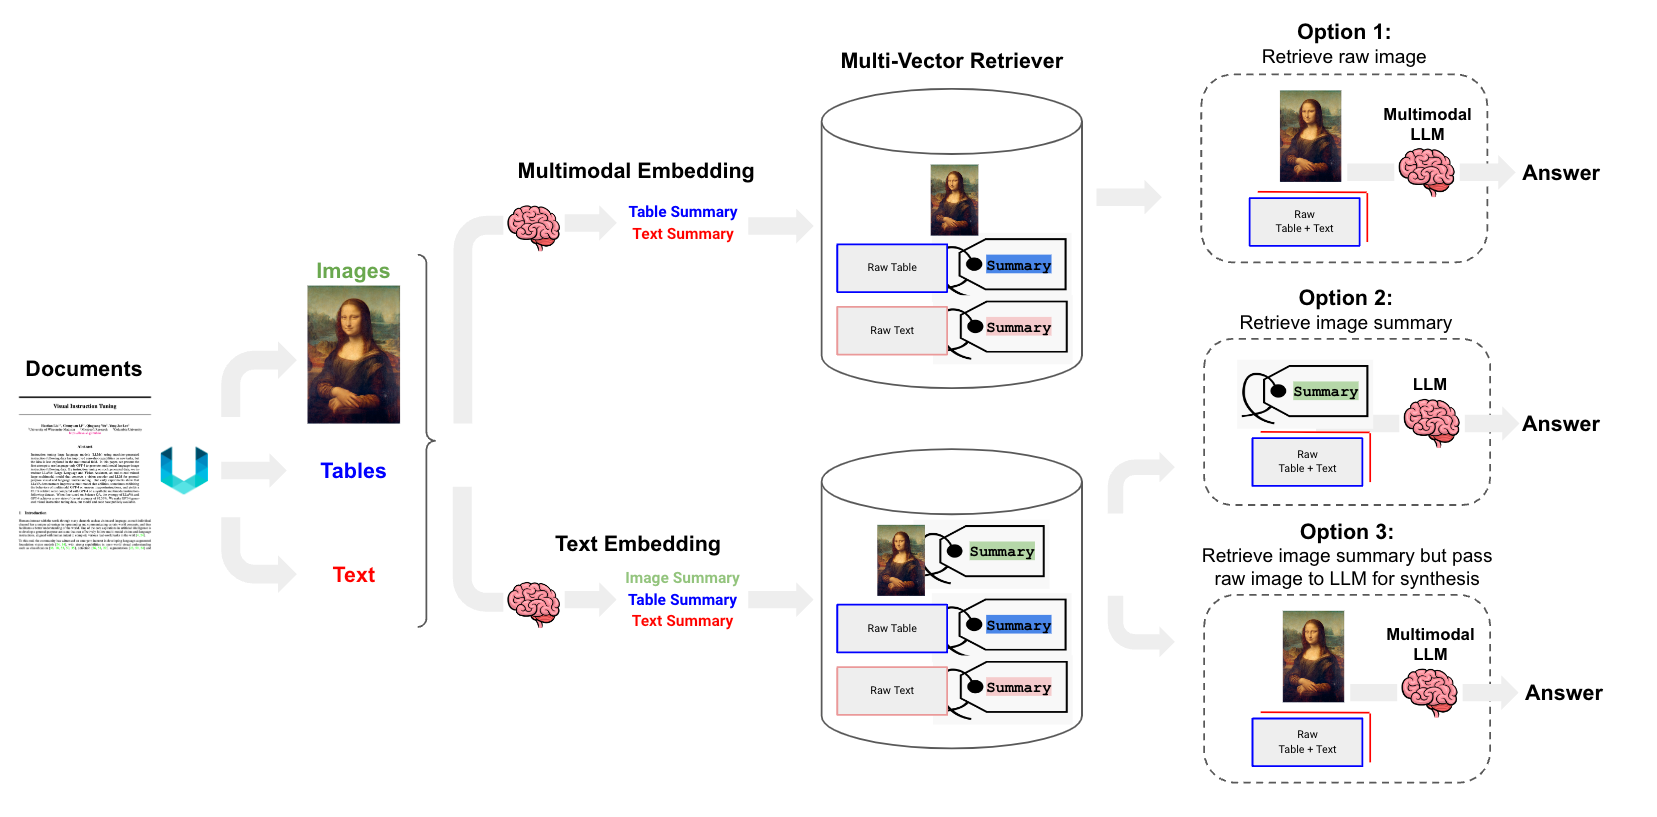

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb

**3가지 옵션 비교:**

| 옵션 | 임베딩 방식 | 벡터 DB 저장 | 답변 생성 LLM | 이미지 활용 | 장점 | 단점 |
|---|---|---|---|---|---|---|
| 1 | 멀티모달 (CLIP) | 이미지 임베딩, 텍스트 임베딩 | Multimodal | 직접 활용 (base64) | 최고 이미지 활용도, 높은 답변 품질 | 높은 비용, base64 오버헤드 |
| 2 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약) | Text-only | 텍스트 요약 간접 활용 | 비용 효율성, 텍스트 RAG 인프라 활용 | 이미지 정보 손실, 답변 품질 제한적 |
| 3 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약 + 참조) | Multimodal | 원본 이미지 참조 활용 | 옵션 1과 2의 절충, 이미지 정보 손실 감소, 유연성 | 옵션 1보다 이미지 활용도 낮음, 이미지 참조 관리 필요 |

**선택 가이드:**

* **최고 품질 답변:** 옵션 1 (비용 고려)
* **비용 효율성 우선:** 옵션 2 (답변 품질 제한 감수)
* **품질과 효율성 균형:** 옵션 3

---

`(1) Env 환경변수`

In [ ]:
from dotenv import load_dotenv
load_dotenv()

`(2) 기본 라이브러리`

In [ ]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

`(3) langfuse handler 설정`

In [ ]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

---

## **회사 소개자료 문서 로드**

- PDF 문서에서 이미지, 텍스트, 테이블 분리


### 1. **데이터 로딩 및 파싱** 

- 메모리 부족할 경우 별도의 실습파일을 활용 

In [ ]:
# 데이터 저장 폴더 경로
data_path = "data/ir_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

In [ ]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
chunks = partition_pdf(
    filename=pdf_files[0],  # 첫 번째 PDF 파일을 선택
    strategy="hi_res",              
    infer_table_structure=True,    
    languages=["eng", "kor"],           
    
    # 이미지 추출 설정     
    extract_image_block_types=["Image", "Table"],
    extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
    # extract_image_block_to_payload=True, # base64로 저장

    # 후처리 설정
    post_processors=[
        group_broken_paragraphs,
        clean_extra_whitespace,
        ], 

    # 문서 청킹 설정
    chunking_strategy="by_title",
    max_characters=2000,   
    new_after_n_chars=1600,
    combine_text_under_n_chars=1000,    

)

# 청크 개수 확인
print(len(chunks))

In [ ]:
# 청크 내용 확인
for chunk in chunks[1:3]:
    print(chunk)
    print("=" * 100)

In [ ]:
# 타입별 분석
chunk_types = {}
for chunk in chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

In [ ]:
# 청크 저장
import pickle

with open(os.path.join(data_path, "pdf_image_chunks.pkl"), "wb") as f:
    pickle.dump(chunks, f)

In [ ]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_image_chunks.pkl"), "rb") as f: 
    chunks = pickle.load(f)

# 청크 개수 확인
print(len(chunks))

### 2. **타입별 구조 확인** 

In [ ]:
# CompositeElement 확인
chunks[0]

In [ ]:
# CompositeElement는 하위 구성 요소를 포함하고 있음
chunks[1].metadata.orig_elements

In [ ]:
# 이미지와 테이블 수 계산
image_count = 0
table_count = 0

for chunk in chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for element in chunk.metadata.orig_elements:
            element_type = str(type(element))
            if 'Image' in element_type:
                image_count += 1
            elif 'Table' in element_type:
                table_count += 1

print(f"\n🖼️ 추출된 이미지: {image_count}개")
print(f"📊 추출된 테이블: {table_count}개")

In [ ]:
# Image 객체 확인
img = chunks[1].metadata.orig_elements[1]
img.to_dict()

In [ ]:
from PIL import Image


# 이미지 로드
img_path = img.metadata.image_path
pil_img = Image.open(img_path)

# 이미지 출력
pil_img.show()

In [ ]:
# Table 요소를 포함하고 있음
chunks[-2].metadata.orig_elements

In [ ]:
# Table 객체 확인
chunks[-2].metadata.orig_elements[-13].to_dict()

In [ ]:
# Table 객체를 pandas DataFrame으로 변환
tab = chunks[-2].metadata.orig_elements[-13]
tab_df = pd.read_html(tab.metadata.text_as_html)[0]

tab_df.head()

In [ ]:
# Table 객체를 마크다운 형식으로 변환
tab_md = tab_df.to_markdown()
print(tab_md)

In [ ]:
# Table 객체 이미지 확인
pil_img = Image.open(tab.metadata.image_path)

# 이미지 출력
pil_img.show()

---

## **[옵션 1]** 멀티모달 임베딩 (CLIP) 사용

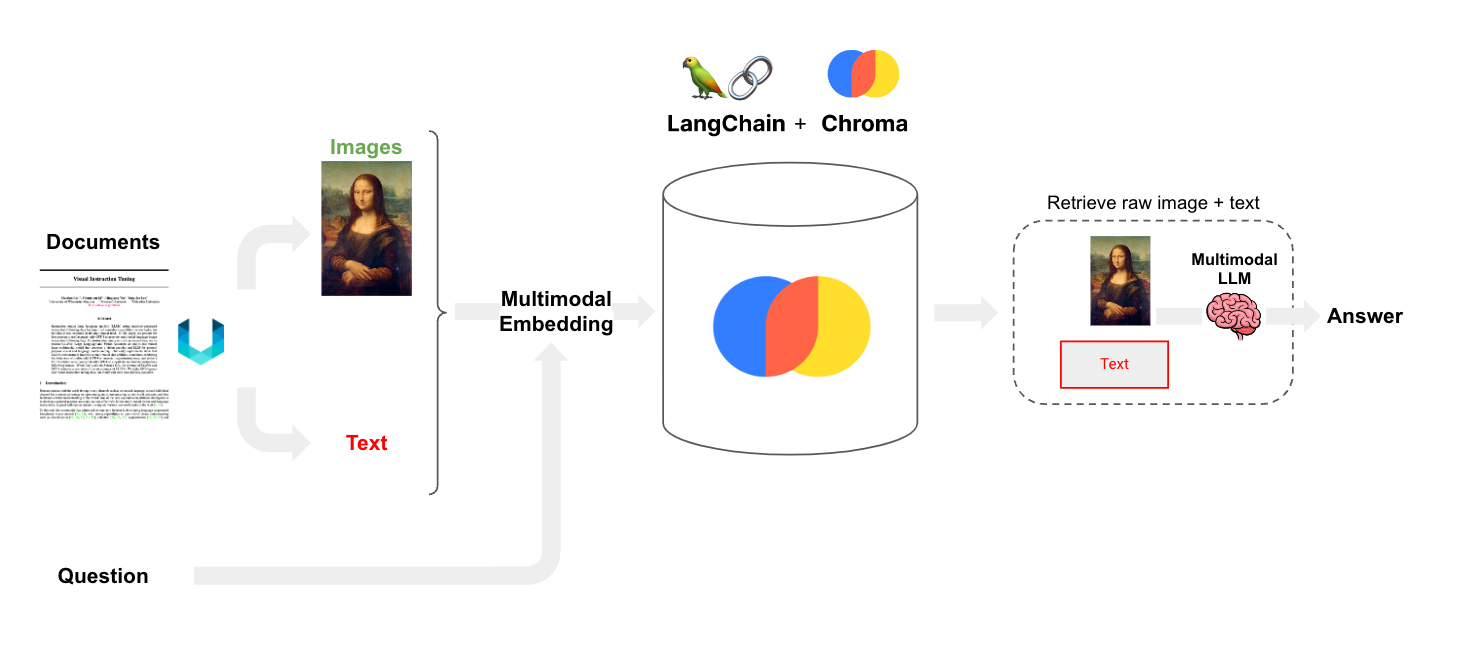

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/multi_modal_RAG_chroma.ipynb

### 1. **임베딩 변환 및 인덱싱** 

- Table, Text 요소를 모두 같은 임베딩 모델을 사용하여 변환

`(1) 다국어 CLIP 모델 준비`

In [ ]:
from langchain_experimental.open_clip import OpenCLIPEmbeddings

# OpenCLIPEmbeddings 임베딩 모델 초기화
clip_embedding_model = OpenCLIPEmbeddings(
    model_name="xlm-roberta-base-ViT-B-32",
    checkpoint="laion5b_s13b_b90k",
)  #type: ignore

In [ ]:
# 이미지 임베딩 
img_embedding = clip_embedding_model.embed_image([img.metadata.image_path, tab.metadata.image_path])
img_embedding = np.array(img_embedding)
print(img_embedding.shape)

In [ ]:
# 텍스트 임베딩
text_embedding = clip_embedding_model.embed_documents(["businessman", tab.text])
text_embedding = np.array(text_embedding)
print(text_embedding.shape)

In [ ]:
# 유사도 계산
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(img_embedding, text_embedding)

# 유사도 시각화
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.heatmap(similarity, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Text Embedding")
plt.ylabel("Image Embedding")
plt.xticks(ticks=[0.5, 1.5], labels=["businessman", "tab.text"])
plt.yticks(ticks=[0.5, 1.5], labels=["Image", "Table"] , rotation=0)
plt.show()

`(2) DB 인덱싱`

- **멀티모달 임베딩**을 활용하여 문서와 이미지를 함께 처리
- **Chroma** 벡터 데이터베이스를 생성하여 **OpenCLIPEmbeddings**를 임베딩 함수로 사용

In [ ]:
from langchain_chroma import Chroma

# Chroma DB 초기화
vectorstore = Chroma(
    collection_name="mm_rag_clip_ir", embedding_function=clip_embedding_model
)

# PDF 파일에서 추출한 이미지 경로 (jpg 파일)
image_uris = sorted(
    [
        os.path.join(image_output_dir, image_name)
        for image_name in os.listdir(image_output_dir)
        if image_name.endswith(".jpg")
    ]
)

# 이미지를 벡터스토어에 추가
vectorstore.add_images(uris=image_uris)

# 텍스트를 벡터스토어에 추가
vectorstore.add_texts(texts=[chunk.text for chunk in chunks])

In [ ]:
import os
from PIL import Image
from langchain_chroma import Chroma

# 노이즈를 걸러낼 최소 폭/높이 설정 (예: 100x100 픽셀 이상만 허용)
MIN_WIDTH = 100
MIN_HEIGHT = 100

vectorstore = Chroma(
    collection_name="mm_rag_clip_ir", embedding_function=clip_embedding_model
)

valid_image_uris = []
total_image_count = 0  # 전체 이미지 갯수를 저장할 변수

for image_name in os.listdir(image_output_dir):
    if image_name.endswith(".jpg"):
        total_image_count += 1
        img_path = os.path.join(image_output_dir, image_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                # 너비와 높이가 모두 기준치 이상인 이미지만 추가
                if width >= MIN_WIDTH and height >= MIN_HEIGHT:
                    valid_image_uris.append(img_path)
        except Exception as e:
            print(f"이미지 읽기 오류: {img_path} - {e}")

image_uris = sorted(valid_image_uris)

# ====== 이미지 갯수 전후 비교 출력 ======
print(f"필터링 전 원본 이미지 갯수 : {total_image_count}개")
print(f"필터링 후 유효 이미지 갯수 : {len(image_uris)}개")
print(f"제거된 노이즈 이미지 갯수 : {total_image_count - len(image_uris)}개")
print("========================================")

# 검증된 이미지만 벡터스토어에 추가
if image_uris:
    vectorstore.add_images(uris=image_uris)
    
if chunks:
    vectorstore.add_texts(texts=[chunk.text for chunk in chunks])


In [ ]:
# 벡터스토어 검색을 위한 retriever 생성
retriever = vectorstore.as_retriever(search_kwargs={"k": 40})

### 2. **RAG** 

- **vectorstore.add_images** 함수는 이미지를 **base64 인코딩 문자열**로 저장
- 이미지가 벡터스토어에 저장될 때 원본 형식이 아닌 **인코딩된 형태**로 변환됨 
- 검색(retrieval) 시에도 이미지는 **base64 문자열**로 반환
- 필요한 경우 반환된 base64 문자열을 다시 **디코딩**하여 원본 이미지로 변환 가능

`(1) 전처리 함수`

- **is_base64()** 함수는 문자열이 Base64로 인코딩되었는지 확인
- **split_image_text_types()** 함수는 문서 배열에서 이미지와 텍스트를 분리하여 각각 별도의 배열로 저장

In [ ]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            # 서버 오류를 방지하기 위해 이미지 크기 조정 
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))
    

In [ ]:
# 벡터 스토어에서 문서 검색 
# 참고: k 파라미터는 invoke()에서 직접 받지 않습니다.
# retriever 생성 시 search_kwargs={"k": 40}으로 설정하세요.
docs = retriever.invoke("A man wearing in a formal suit")

# 검색된 각 문서 처리
for doc in docs:
    # 문서 내용이 Base64 인코딩된 이미지인 경우
    if is_base64(doc.page_content):
        plt_img_base64(doc.page_content)  # 이미지 표시
        print("=" * 100)
    else:
        print(doc.page_content[:50])  # 텍스트 내용 출력
        print("=" * 100)

In [ ]:
# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("도시가스 사업 매출실적")

# 검색된 각 문서 처리
for doc in docs:
    # 문서 내용이 Base64 인코딩된 이미지인 경우
    if is_base64(doc.page_content):
        plt_img_base64(doc.page_content)  # 이미지 표시
        print("=" * 100)
    else:
        print(doc.page_content[:50])  # 텍스트 내용 출력
        print("=" * 100)

`(2) RAG 파이프라인`

- **prompt_func 함수**는 검색된 컨텍스트와 사용자 질문을 결합하여 모델에 전달할 **프롬프트**를 생성
- 파이프라인은 **검색 및 데이터 준비**와 **생성** 두 단계로 구성

In [ ]:
from operator import itemgetter
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI

def create_system_message():
    """
    시스템 메시지를 생성한다.
    반환값:
    SystemMessage: 재무 분석가 역할을 정의하는 시스템 메시지
    """
    system_content = (
        "당신은 재무 분석가이자 기업 평가 전문가이다. "
        "당신의 임무는 기업 보고서와 IR 자료를 분석하고 해석하는 것이다. "
        "이미지(차트, 그래프 등)와 함께 관련 텍스트가 제공되어 맥락을 제공할 것이다. "
        "이들은 모두 사용자 입력 키워드를 기반으로 벡터 스토어에서 검색된다. "
        "다음을 포함하는 포괄적인 분석을 제공하기 위해 재무 지식과 분석 기술을 활용한다:\n"
        "- 제시된 재무 데이터 및 시각 자료에 대한 상세한 설명\n"
        "- 기업의 현재 재무 상태와 시장 위치에 대한 분석\n"
        "- 주요 재무 지표의 추세 및 의미 해석\n"
        "- 잠재적 투자 기회 또는 위험 요소 식별\n"
        "- 동종 업계 내 경쟁사와의 비교 분석"
    )
    return SystemMessage(content=system_content)

def prompt_func(data_dict):
    """
    데이터 딕셔너리를 받아 모델에 전달할 프롬프트 메시지를 생성한다.
    매개변수:
    data_dict (dict): 컨텍스트와 질문을 포함하는 딕셔너리
    반환값:
    list: SystemMessage와 HumanMessage 객체를 포함하는 리스트
    """
    # 컨텍스트 텍스트를 하나의 문자열로 결합
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    
    # 멀티모달 콘텐츠 리스트 생성
    content_blocks = []
    
    # 모든 이미지를 콘텐츠 블록에 추가
    if data_dict["context"]["images"]:
        for image_data in data_dict["context"]["images"]:
            image_block = {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image_data}"
                },
            }
            content_blocks.append(image_block)
    
    # 텍스트 콘텐츠 블록 추가
    text_content = (
        f"사용자 제공 키워드: {data_dict['question']}\n\n"
        "텍스트 및/또는 표:\n"
        f"{formatted_texts}"
    )
    
    text_block = {
        "type": "text",
        "text": text_content
    }
    content_blocks.append(text_block)
    
    # 시스템 메시지와 휴먼 메시지를 분리하여 반환
    return [
        create_system_message(),
        HumanMessage(content=content_blocks)
    ]

# GPT-4 멀티모달 모델 초기화 
model = ChatOpenAI(temperature=0, model="gpt-4.1-mini")

# RAG 파이프라인 구성
chain = (
    {
        "context": retriever | RunnableLambda(split_image_text_types),  # 검색된 데이터를 이미지와 텍스트로 분리
        "question": RunnablePassthrough(),  # 원본 질문을 그대로 전달
    }
    | RunnableLambda(prompt_func)  # 프롬프트 메시지 생성
    | model  # 모델에 프롬프트 전달
    | StrOutputParser()  # 모델 출력을 문자열로 변환
)

In [ ]:
# chain 실행
# Langfuse 트레이싱 활성화:
# result = chain.invoke(query, config={"callbacks": [langfuse_handler]})
result = chain.invoke("도시가스 사업 매출실적")

# 결과 출력
print(result)

In [ ]:
# chain 실행
# Langfuse 트레이싱 활성화:
# result = chain.invoke(query, config={"callbacks": [langfuse_handler]})
result = chain.invoke("도시 가스 공장 설비 및 인프라에 대한 설명")

# 결과 출력
print(result)

---
## **[실습]**

- 트랜스포머 논문(data/transformer.pdf)에 대한 CLIP 임베딩 기반 RAG 시스템을 구현합니다. 

In [ ]:
# 여기에 코드를 작성하세요.